
FIFA WORLD CUP DATA ANALYSIS (2014-2026)

 Matches by Year:
Year
2006     3
2010     3
2014     6
2016     1
2018    11
2022    16
2026     8
Name: count, dtype: int64

 TOP 10 TEAMS - TOTAL GOALS:
Home Team
Germany        13.0
Brazil         12.0
England         9.0
France          9.0
Argentina       7.0
Japan           7.0
Portugal        6.0
Canada          6.0
Italy           6.0
Netherlands     6.0
dtype: float64


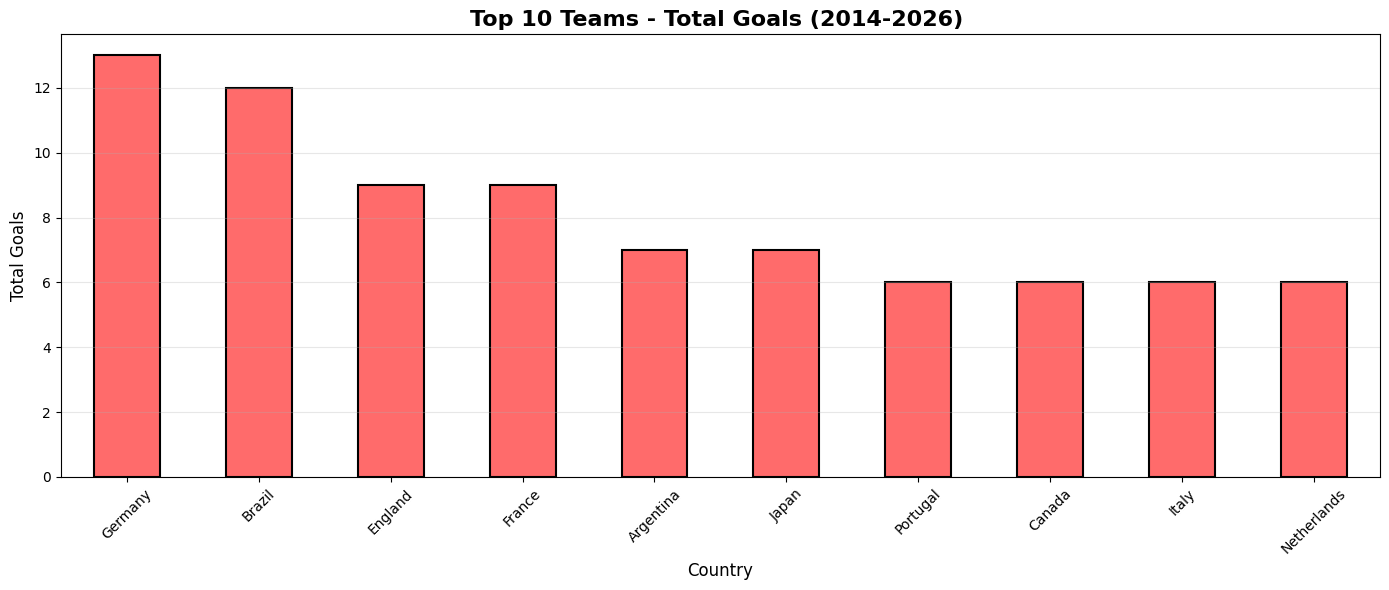

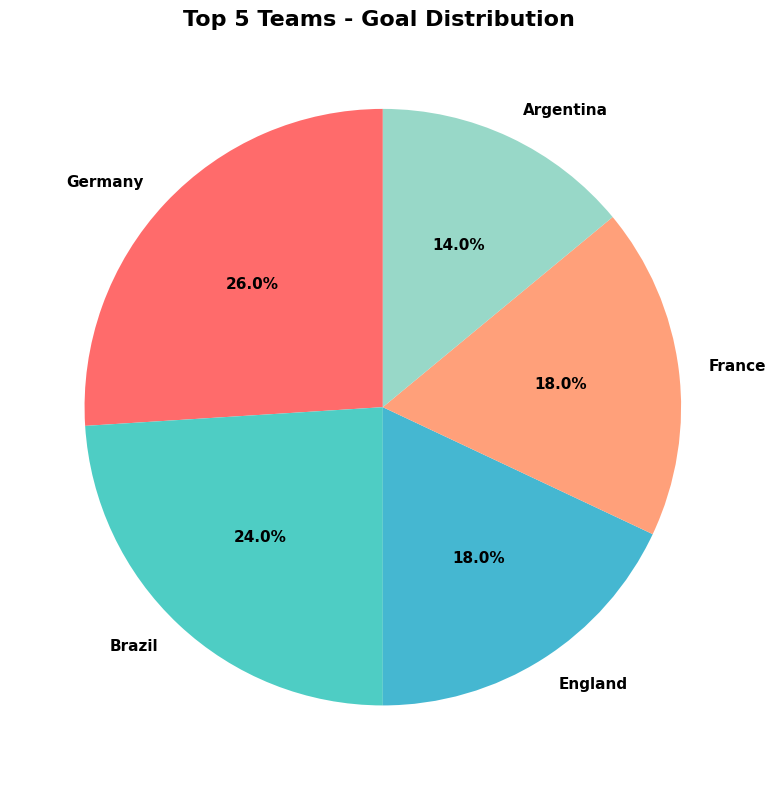


 MATCH RESULTS (All Time):
Home Wins: 44 🏠
Away Wins: 1 ✈️
Draws: 3 


C:\Users\Nirmal Saud\AppData\Local\Temp\ipykernel_14680\2812524750.py:74: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nirmal Saud\AppData\Local\Temp\ipykernel_14680\2812524750.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nirmal Saud\AppData\Local\Temp\ipykernel_14680\2812524750.py:75: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.savefig('results_chart.png', dpi=100)
C:\Users\Nirmal Saud\AppData\Local\Temp\ipykernel_14680\2812524750.py:75: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('results_chart.png', dpi=100)
C:\Users\Nirmal Saud\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Nirmal Saud\AppData\Roaming\Pytho

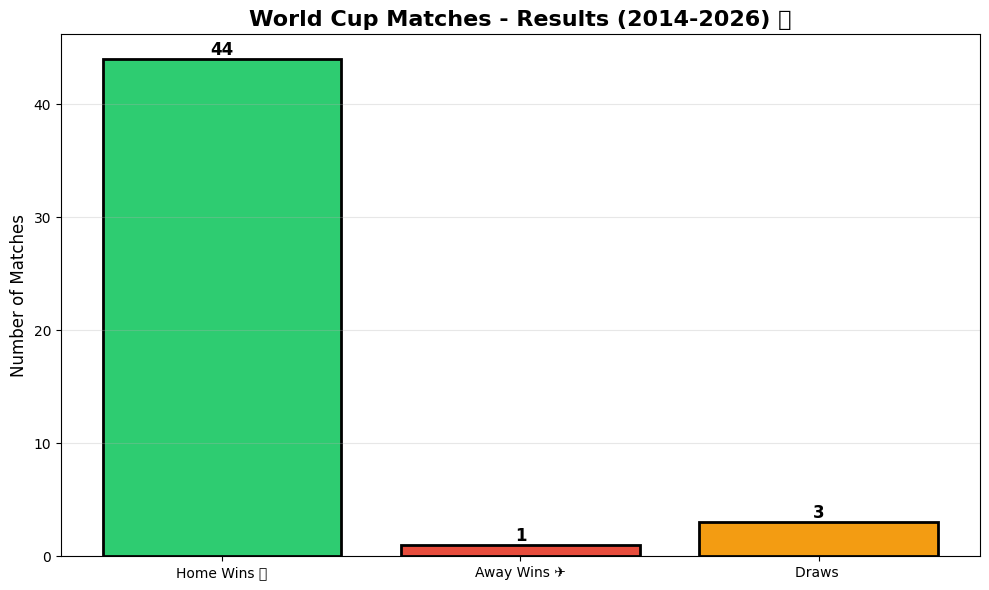

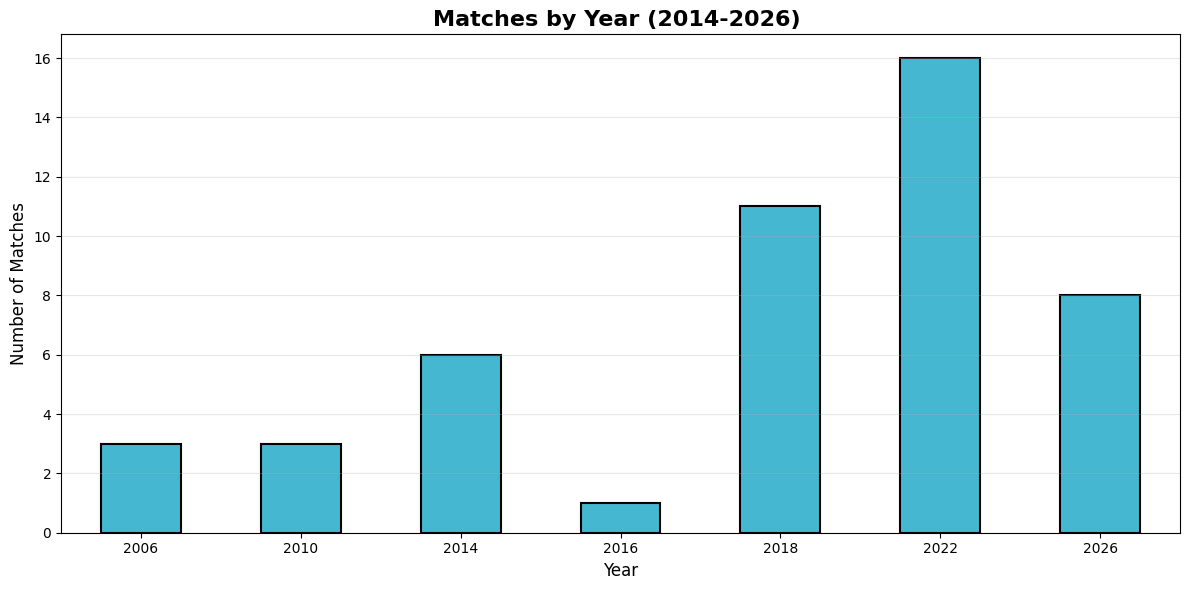


 Analysis Complete!
 Charts saved:
   - goals_chart.png
   - top5_pie.png
   - results_chart.png
   - years_chart.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data load गर
df = pd.read_csv('world_cup_data.csv')

print("\n" + "="*60)
print("FIFA WORLD CUP DATA ANALYSIS (2014-2026)")
print("="*60)

# 1. Year को analysis
print("\n Matches by Year:")
year_counts = df['Year'].value_counts().sort_index()
print(year_counts)

# 2. Top Scorers
goals_home = df.groupby('Home Team')['Home Team Goals'].sum()
goals_away = df.groupby('Away Team')['Away Team Goals'].sum()
total_goals = goals_home.add(goals_away, fill_value=0).sort_values(ascending=False)

print("\n TOP 10 TEAMS - TOTAL GOALS:")
print(total_goals.head(10))

# 3. Chart 1: Bar Chart - Top Teams
plt.figure(figsize=(14, 6))
total_goals.head(10).plot(kind='bar', color='#FF6B6B', edgecolor='black', linewidth=1.5)
plt.title('Top 10 Teams - Total Goals (2014-2026) ', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Goals', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('goals_chart.png', dpi=100)
plt.show()

# 4. Chart 2: Pie Chart - Top 5
plt.figure(figsize=(10, 8))
top_5 = total_goals.head(5)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.pie(top_5, labels=top_5.index, autopct='%1.1f%%', colors=colors, startangle=90, 
        textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Top 5 Teams - Goal Distribution ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('top5_pie.png', dpi=100)
plt.show()

# 5. Wins Analysis
home_wins = (df['Home Team Goals'] > df['Away Team Goals']).sum()
away_wins = (df['Away Team Goals'] > df['Home Team Goals']).sum()
draws = (df['Home Team Goals'] == df['Away Team Goals']).sum()

print(f"\n MATCH RESULTS (All Time):")
print(f"Home Wins: {home_wins} 🏠")
print(f"Away Wins: {away_wins} ✈️")
print(f"Draws: {draws} ")

# 6. Chart 3: Match Results
plt.figure(figsize=(10, 6))
results = [home_wins, away_wins, draws]
labels = ['Home Wins 🏠', 'Away Wins ✈️', 'Draws ']
colors_results = ['#2ecc71', '#e74c3c', '#f39c12']
bars = plt.bar(labels, results, color=colors_results, edgecolor='black', linewidth=2)
plt.title('World Cup Matches - Results (2014-2026) 📊', fontsize=16, fontweight='bold')
plt.ylabel('Number of Matches', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Values को label 
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results_chart.png', dpi=100)
plt.show()

# 7. Year wise Analysis
plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar', color='#45B7D1', edgecolor='black', linewidth=1.5)
plt.title('Matches by Year (2014-2026) ', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('years_chart.png', dpi=100)
plt.show()

print("\n Analysis Complete!")
print(" Charts saved:")
print("   - goals_chart.png")
print("   - top5_pie.png")
print("   - results_chart.png")
print("   - years_chart.png")